# Phase 0: ASF Displacement Portal assets in GeoLibre

This prototype uses only what the ASF portal already publishes:

- **time-series API:** `/frame_intersection` and `/timeseries`, which allow any origin;
- **velocity overview tiles:** OPERA-DISP-TMS, decoded back to m/yr.

It shows them in a GeoLibre map. The browser plugin (Phase 1) will do the same through our proxy.

**Product caveats**
- `short_wavelength_displacement` only: long-wavelength signal is filtered out.
- Tiles are quantized to 0.24 mm/yr and clipped at ±3 cm/yr.
- Tiles were last generated on 2025-11-11.

See `PHASE0_NOTES.md` for the measured behaviour.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from matplotlib.colors import ListedColormap
from shapely.geometry import box, mapping

from disp_portal import AsfClient, TileFetcher, mosaic, value_at
from disp_portal.tiles import COLOR_LUT, ramp_css_colors

client = AsfClient()
fetcher = TileFetcher(cache_dir="../.cache/tiles")
ASF_CMAP = ListedColormap(COLOR_LUT[1:, :3] / 255.0, name="asf")
TILE_DATE = pd.Timestamp("2025-11-11")


def fit_velocity(df, until=None):
    d = df if until is None else df[df.secondary_datetime <= until]
    t = (d.secondary_datetime - d.secondary_datetime.min()).dt.days / 365.25
    slope, intercept = np.polyfit(t, d.short_wavelength_displacement, 1)
    return slope, intercept, t

## 1. Point time series (both directions)

In [2]:
point = (-95.37, 29.76)  # Houston downtown
series = {}
for direction in ("ascending", "descending"):
    frames = client.frame_intersection(point, direction)
    df = client.timeseries(point, direction)
    series[direction] = df
    print(f"{direction:>10}: frames covering point {sorted(frames)}, API used {sorted(int(f) for f in df.frame_id.unique())}, "
          f"{len(df)} epochs {df.secondary_datetime.min():%Y-%m-%d} .. {df.secondary_datetime.max():%Y-%m-%d}")
series["ascending"].head()

 ascending: frames covering point [8882], API used [8882], 269 epochs 2016-10-09 .. 2026-02-19


descending: frames covering point [38238], API used [38238], 449 epochs 2016-07-24 .. 2026-03-22


,granule,frame_id,reference_datetime,secondary_datetime,temporal_baseline_days,short_wavelength_displacement,x,y,netcdf_uri,direction
0,OPERA_L3_DISP-S1_IW_F08882_VV_20160927T002623Z...,8882,2016-09-27 00:26:23.489,2016-10-09 00:26:23.470,12.0,0.009596,270825.0,3294555.0,s3://asf-cumulus-prod-opera-products/OPERA_L3_...,ascending
1,OPERA_L3_DISP-S1_IW_F08882_VV_20160927T002623Z...,8882,2016-09-27 00:26:23.489,2016-10-21 00:26:23.357,24.0,0.015839,270825.0,3294555.0,s3://asf-cumulus-prod-opera-products/OPERA_L3_...,ascending
2,OPERA_L3_DISP-S1_IW_F08882_VV_20160927T002623Z...,8882,2016-09-27 00:26:23.489,2016-11-02 00:26:23.418,36.0,0.012148,270825.0,3294555.0,s3://asf-cumulus-prod-opera-products/OPERA_L3_...,ascending
3,OPERA_L3_DISP-S1_IW_F08882_VV_20160927T002623Z...,8882,2016-09-27 00:26:23.489,2016-11-14 00:26:23.274,48.0,0.011917,270825.0,3294555.0,s3://asf-cumulus-prod-opera-products/OPERA_L3_...,ascending
4,OPERA_L3_DISP-S1_IW_F08882_VV_20160927T002623Z...,8882,2016-09-27 00:26:23.489,2016-11-26 00:26:23.079,60.0,0.007302,270825.0,3294555.0,s3://asf-cumulus-prod-opera-products/OPERA_L3_...,ascending


Text(0.5, 1.0, 'ASF /timeseries at (-95.37, 29.76)')

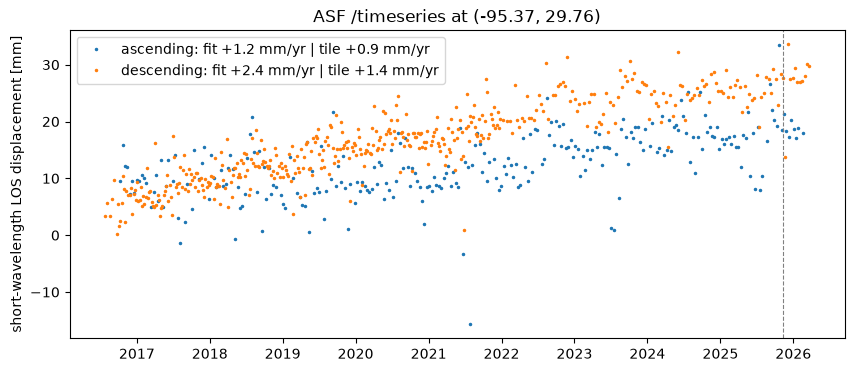

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
for direction, df in series.items():
    slope, intercept, t = fit_velocity(df, TILE_DATE)
    tile_v = value_at(*point, direction, fetcher=fetcher)
    ax.plot(df.secondary_datetime, 1000 * df.short_wavelength_displacement, ".", ms=3,
            label=f"{direction}: fit {1000*slope:+.1f} mm/yr | tile {1000*tile_v:+.1f} mm/yr")
ax.axvline(TILE_DATE, color="gray", ls="--", lw=0.8)
ax.set_ylabel("short-wavelength LOS displacement [mm]")
ax.legend()
ax.set_title(f"ASF /timeseries at {point}")

## 2. Decoded velocity overview (EPSG:3857)

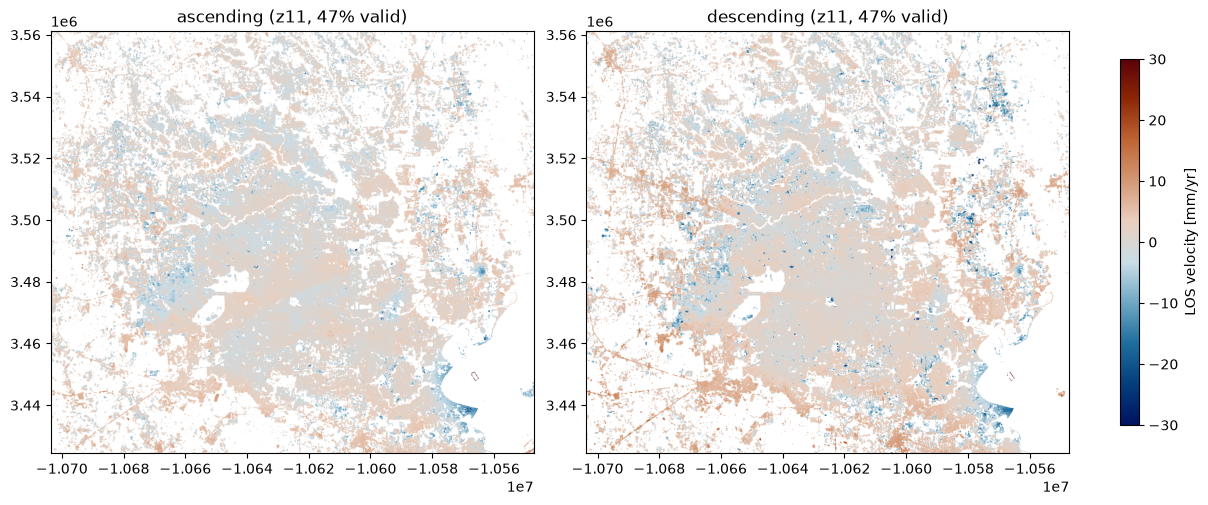

In [4]:
bbox = (-96.0, 29.4, -94.9, 30.3)  # Houston
vel = {d: mosaic(bbox, d, "vel", z=11, fetcher=fetcher) for d in ("ascending", "descending")}
fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)
for ax, (d, da) in zip(axes, vel.items()):
    im = ax.imshow(1000 * da.values, cmap=ASF_CMAP, vmin=-30, vmax=30,
                   extent=[da.x.min(), da.x.max(), da.y.min(), da.y.max()])
    ax.set_title(f"{d} (z{da.attrs['zoom']}, {np.isfinite(da.values).mean():.0%} valid)")
fig.colorbar(im, ax=axes, label="LOS velocity [mm/yr]", shrink=0.8)

## 3. GeoLibre map

The decoded rasters are added as float layers, so Identify returns m/yr.
The ASF tile URLs themselves cannot be used here, because their CORS policy only allows the ASF portal.

In [5]:
from geolibre import Map

m = Map(center=(-95.4, 29.8), zoom=9)
for d, da in vel.items():
    m.add_raster(da, name=f"ASF velocity {d}", colormap="coolwarm", rescale=[[-0.03, 0.03]],
                 array_args={"nodata": np.nan})
m.add_colorbar(colors=ramp_css_colors(), vmin=-30, vmax=30, units="mm/yr",
               label="LOS velocity (ASF overview)")
m

## 4. Click the map to fetch time series

In [6]:
out = widgets.Output()


def on_click(event):
    lng, lat = event["lngLat"]
    with out:
        out.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(9, 3.5))
        for direction in ("ascending", "descending"):
            try:
                df = client.timeseries((lng, lat), direction)
            except Exception as e:  # show service messages (no frame / no valid data) to the user
                print(f"{direction}: {e}")
                continue
            ax.plot(df.secondary_datetime, 1000 * df.short_wavelength_displacement, ".", ms=3,
                    label=f"{direction} F{df.frame_id.iloc[0]:05d}")
        ax.set_title(f"{lng:.4f}, {lat:.4f}")
        ax.set_ylabel("mm")
        ax.legend()
        plt.show()


m.on_click(on_click)
out

Output()

## 5. Polygon: ASF aggregate time series vs zonal statistics from tiles

`/timeseries` with a polygon returns one aggregated value per epoch.
The decoded tiles give the per-pixel distribution inside the same polygon.

In [7]:
aoi = box(-95.82, 29.77, -95.78, 29.81)  # ~4 km box near Katy
df_poly = client.timeseries(aoi, "ascending")
slope_poly, *_ = fit_velocity(df_poly, TILE_DATE)

z12 = mosaic(aoi.bounds, "ascending", "vel", z=12, fetcher=fetcher)
inside = z12.rio.clip([mapping(aoi)], crs="EPSG:4326", drop=True)
v = inside.values[np.isfinite(inside.values)]
print(f"polygon time series: {len(df_poly)} epochs, fitted slope {1000*slope_poly:+.2f} mm/yr")
print(f"tile pixels in polygon: n={v.size}, mean {1000*v.mean():+.2f}, median {1000*np.median(v):+.2f}, "
      f"p5/p95 {1000*np.percentile(v, 5):+.2f}/{1000*np.percentile(v, 95):+.2f} mm/yr")

polygon time series: 269 epochs, fitted slope -3.19 mm/yr
tile pixels in polygon: n=15048, mean -2.66, median -2.60, p5/p95 -5.67/+0.24 mm/yr
